In [2]:
import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import scipy.io as sio

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (15, 5)

***.mat to .csv Processing***

In [11]:
file_path = '/home/ju1ian/Documents/EMG Classification/Data (Ninapro)/raw/s1/S1_A1_E1.mat'
output_csv_path =  '/home/ju1ian/Documents/EMG Classification/Data (Ninapro)/processed/ninapro_db1_ready.csv'

print(f"Reading data from {file_path}")

mat_data = sio.loadmat(file_path) 

emg_data = mat_data['emg']
restimulus = mat_data['restimulus']
repetition = mat_data['repetition']

combined_data = np.hstack((emg_data, restimulus, repetition))

column_names = [f'emg_ch{i+1}' for i in range(10)] + ['restimulus','repetition']

df = pd.DataFrame(combined_data, columns=column_names)

df['restimulus'] = df['restimulus'].astype(int)
df['repetition'] = df['repetition'].astype(int)
 
df.to_csv(output_csv_path, index=False)

print(f"\n File extracted successfully: {output_csv_path}")
print(f"Shape: {df.shape[0]} sampes x {df.shape[1]}")
print("\n dataset exp:")
print(df.head())

Reading data from /home/ju1ian/Documents/EMG Classification/Data (Ninapro)/raw/s1/S1_A1_E1.mat

 File extracted successfully: /home/ju1ian/Documents/EMG Classification/Data (Ninapro)/processed/ninapro_db1_ready.csv
Shape: 101014 sampes x 12

 dataset exp:
   emg_ch1  emg_ch2  emg_ch3  emg_ch4  emg_ch5  emg_ch6  emg_ch7  emg_ch8  \
0   0.0684   0.0024   0.0024   0.0024   0.0024   0.0098   0.0024   0.0488   
1   0.0586   0.0024   0.0024   0.0024   0.0024   0.0049   0.0024   0.0415   
2   0.0562   0.0024   0.0024   0.0024   0.0024   0.0049   0.0024   0.0391   
3   0.0562   0.0024   0.0024   0.0024   0.0024   0.0049   0.0024   0.0342   
4   0.0488   0.0024   0.0024   0.0024   0.0024   0.0024   0.0024   0.0366   

   emg_ch9  emg_ch10  restimulus  repetition  
0   0.0024    0.0342           0           0  
1   0.0024    0.0293           0           0  
2   0.0024    0.0244           0           0  
3   0.0024    0.0171           0           0  
4   0.0024    0.0146           0           0  

***Data Visualization***

/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7901 (\N{LATIN SMALL LETTER O WITH HORN AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_20615/1398754053.py:47: UserWarning: Glyph 7917 (\N{LATIN SMALL LETTER U WITH HORN AND HOOK ABOVE}) missing 

Saved plot to emg_with_labels.png
Plotted from sample 0 to 5000


/home/ju1ian/miniconda3/envs/eend-vd/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7897 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ju1ian/miniconda3/envs/eend-vd/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7879 (\N{LATIN SMALL LETTER E WITH CIRCUMFLEX AND DOT BELOW}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ju1ian/miniconda3/envs/eend-vd/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7889 (\N{LATIN SMALL LETTER O WITH CIRCUMFLEX AND ACUTE}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ju1ian/miniconda3/envs/eend-vd/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 7847 (\N{LATIN SMALL LETTER A WITH CIRCUMFLEX AND GRAVE}) missing from font(s) Liberation Sans.
  fig.canvas.p

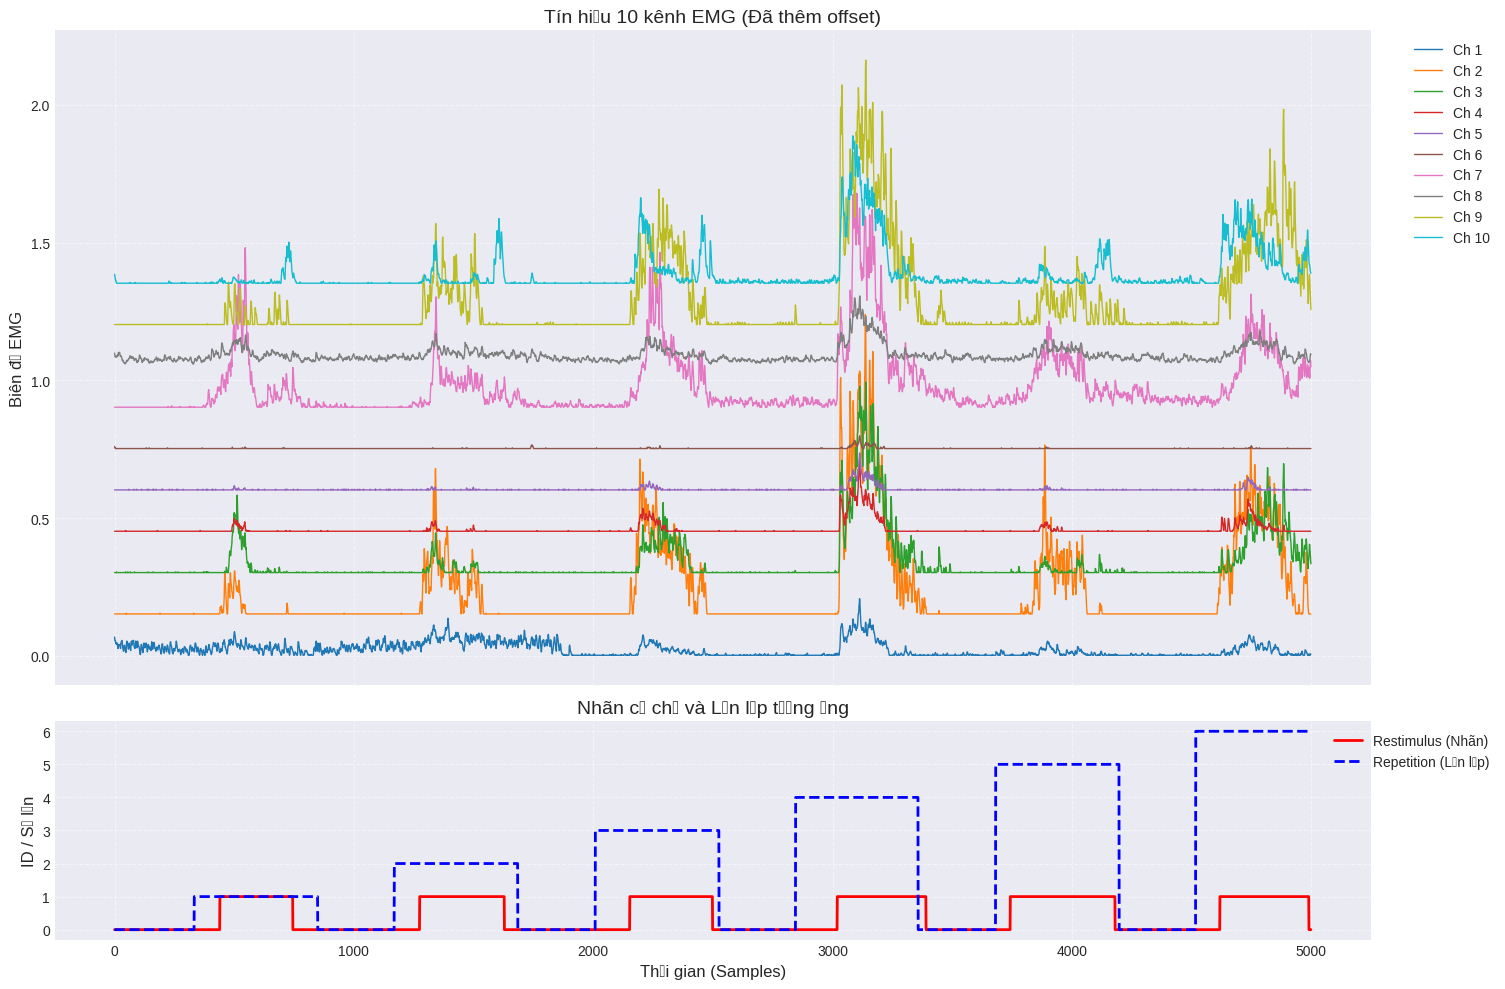

In [13]:

# Đọc file CSV
df = pd.read_csv(output_csv_path)

# Tìm khoảng dữ liệu có chứa hành động (restimulus > 0)
# Nghỉ ngơi (0) chiếm đa số, nên ta tìm lần co cơ đầu tiên
action_indices = df.index[df['restimulus'] > 0].tolist()

if action_indices:
    # Lấy mẫu bắt đầu từ trước khi có hành động 1000 samples, 
    # và kéo dài khoảng 5000 samples để thấy rõ cả nghỉ và làm
    start_idx = max(0, action_indices[0] - 1000)
    end_idx = min(len(df), start_idx + 5000)
else:
    # Nếu không tìm thấy, lấy 5000 mẫu đầu tiên
    start_idx = 0
    end_idx = min(len(df), 5000)

df_subset = df.iloc[start_idx:end_idx].copy()
time_axis = np.arange(start_idx, end_idx)

# Bắt đầu vẽ
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

# 1. Vẽ 10 kênh EMG trên trục trên (ax1)
colors = plt.cm.tab10(np.linspace(0, 1, 10))
for i in range(10):
    # Cột EMG từ 0 đến 9
    col_name = f'emg_ch{i+1}'
    # Cộng thêm offset để tách biệt các đường
    ax1.plot(time_axis, df_subset[col_name] + i*0.15, label=f'Ch {i+1}', color=colors[i], linewidth=1)

ax1.set_title('Tín hiệu 10 kênh EMG (Đã thêm offset)', fontsize=14)
ax1.set_ylabel('Biên độ EMG', fontsize=12)
ax1.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Vẽ Nhãn (restimulus) và Lần lặp (repetition) trên trục dưới (ax2)
ax2.plot(time_axis, df_subset['restimulus'], color='red', label='Restimulus (Nhãn)', linewidth=2)
ax2.plot(time_axis, df_subset['repetition'], color='blue', linestyle='--', label='Repetition (Lần lặp)', linewidth=2)

ax2.set_title('Nhãn cử chỉ và Lần lặp tương ứng', fontsize=14)
ax2.set_xlabel('Thời gian (Samples)', fontsize=12)
ax2.set_ylabel('ID / Số lần', fontsize=12)
ax2.legend(loc='upper right', bbox_to_anchor=(1.1, 1))
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('emg_with_labels.png', dpi=300, bbox_inches='tight')
print("Saved plot to emg_with_labels.png")
print(f"Plotted from sample {start_idx} to {end_idx}")